# 🏨 Azure Stay Hotel — Channel Profitability Analysis
### ปัญหา 2: ต้นทุนการกระจายสินค้าสูง (High Distribution Costs)
> **กลุ่ม:** 143, 144, 152  
> **รายวิชา:** DS512 / DS513 — Data Analytics  
> **ชุดข้อมูล:** ข้อมูลสังเคราะห์โดย AI (4 ตาราง, 1,150 การจอง, ม.ค.–ธ.ค. 2567)


## เซลล์ที่ 0: ติดตั้งและนำเข้าไลบรารี

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

print('✅ Libraries imported successfully')


✅ Libraries imported successfully


## เซลล์ที่ 1: โหลดข้อมูล
**วิธีใช้งานบน Google Colab:**
1. อัปโหลดโฟลเดอร์ `data/` ขึ้น Google Drive
2. ยกเลิก comment บรรทัด Option B และ comment บรรทัด Option A

In [5]:
import os
import pandas as pd

def find_file(filename):
    for root, dirs, files in os.walk('.'):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"{filename} not found")

fact_bookings = pd.read_csv(
    find_file('fact_bookings (1).csv'),
    parse_dates=['booking_date', 'check_in_date']
)

dim_channels = pd.read_csv(find_file('dim_channels (1).csv'))
dim_rate_codes = pd.read_csv(find_file('dim_rate_codes (1).csv'))

fact_mkt_spend = pd.read_csv(
    find_file('fact_marketing_spend (1).csv'),
    parse_dates=['spend_date']
)

print(fact_bookings.shape)

(1150, 11)


## เซลล์ที่ 2: ตรวจสอบคุณภาพข้อมูล (Data Quality Check)

In [6]:
print('===== Data Quality Report =====')

# 1. Check for duplicate Primary Keys
dup_bk = fact_bookings.duplicated(subset='booking_id').sum()
print(f'Duplicate booking_id         : {dup_bk}  (should be 0)')

# 2. Check for null values
for df, name in [(fact_bookings,'fact_bookings'),(dim_channels,'dim_channels'),
                 (dim_rate_codes,'dim_rate_codes'),(fact_mkt_spend,'fact_mkt_spend')]:
    nulls = df.isnull().sum().sum()
    print(f'Nulls in {name:25s}: {nulls}')

# 3. Check Foreign Key integrity
orphan_channels = set(fact_bookings['channel_id']) - set(dim_channels['channel_id'])
print(f'channel_id missing in dim    : {orphan_channels}  (should be empty set)')

# 4. Validate business logic
fact_bookings['net_check'] = (fact_bookings['gross_room_revenue'] - fact_bookings['commission_amount']).round(2)
mismatch = (fact_bookings['net_room_revenue'].round(2) != fact_bookings['net_check']).sum()
print(f'net_room_revenue mismatch    : {mismatch}  (should be 0)')
fact_bookings.drop(columns='net_check', inplace=True)

print('\n✅ All data quality checks passed')


===== Data Quality Report =====
Duplicate booking_id         : 0  (should be 0)
Nulls in fact_bookings            : 0
Nulls in dim_channels             : 0
Nulls in dim_rate_codes           : 0
Nulls in fact_mkt_spend           : 0
channel_id missing in dim    : set()  (should be empty set)
net_room_revenue mismatch    : 0  (should be 0)

✅ All data quality checks passed


## เซลล์ที่ 3: เตรียมข้อมูลหลัก (Join Tables)

In [7]:
df = (fact_bookings
      .merge(dim_channels,   on='channel_id',   how='left')
      .merge(dim_rate_codes,  on='rate_code_id', how='left'))

df['is_cancelled']     = (df['status'] == 'Cancelled').astype(int)
df['month']            = df['booking_date'].dt.to_period('M').astype(str)
df['commission_ratio'] = (df['commission_amount'] / df['gross_room_revenue']).replace([np.inf,-np.inf],0).fillna(0)

active_df = df[df['status'] != 'Cancelled'].copy()

print('Main DataFrame shape:', df.shape)
print(f'Total bookings       : {len(df):,}')
print(f'Checked-Out          : {len(df[df["status"]=="Checked-Out"]):,}')
print(f'Confirmed            : {len(df[df["status"]=="Confirmed"]):,}')
print(f'Cancelled            : {len(df[df["status"]=="Cancelled"]):,}')


Main DataFrame shape: (1150, 21)
Total bookings       : 1,150
Checked-Out          : 727
Confirmed            : 263
Cancelled            : 160


## เซลล์ที่ 4: สมมติฐาน 1 — ช่องทางตรงให้ Net ADR สูงกว่า OTA
### แผนภูมิที่ 1: Gross ADR vs Net ADR ตามช่องทางการจอง

===== Hypothesis 1: Net ADR by Channel Type =====
    channel_name channel_type  gross_adr  comm_pct   net_adr  bookings
0        Walk-in       Direct   13941.41       0.0  13941.41       270
1     Direct Web       Direct   13750.60       0.0  13750.60       180
2        Expedia          OTA   13443.03      18.0  11023.29       123
3  GDS (Amadeus)    Wholesale   10477.59       2.4  10231.26       136
4      Hotelbeds    Wholesale   10527.16      12.7   9191.59       128
5    Booking.com          OTA   10462.61      15.0   8893.22       153


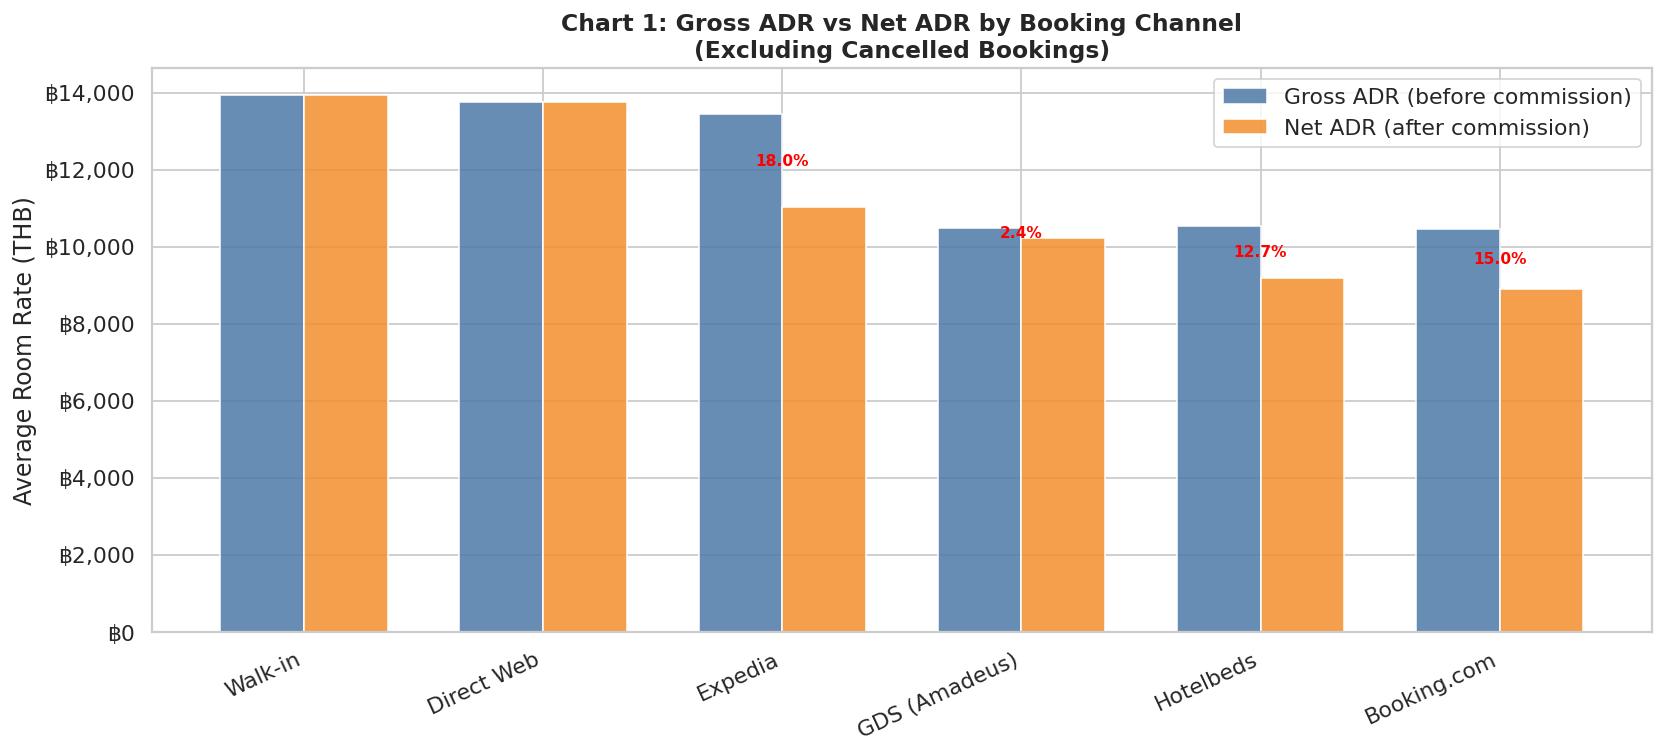

Saved: chart1_gross_vs_net_adr.png


In [8]:
print('===== Hypothesis 1: Net ADR by Channel Type =====')

net_adr_channel = (active_df.groupby(['channel_name','channel_type','commission_model'])
                   .agg(total_gross=('gross_room_revenue','sum'),
                        total_comm =('commission_amount','sum'),
                        total_net  =('net_room_revenue','sum'),
                        bookings   =('booking_id','count'))
                   .assign(net_adr  =lambda x: x['total_net']   / x['bookings'],
                           gross_adr=lambda x: x['total_gross'] / x['bookings'],
                           comm_pct =lambda x: (x['total_comm'] / x['total_gross'] * 100).round(1))
                   .sort_values('net_adr', ascending=False)
                   .reset_index())

print(net_adr_channel[['channel_name','channel_type','gross_adr','comm_pct','net_adr','bookings']].round(2).to_string())

# Chart 1: Grouped Bar Chart
fig, ax = plt.subplots(figsize=(13,6))
x = np.arange(len(net_adr_channel))
w = 0.35

ax.bar(x - w/2, net_adr_channel['gross_adr'], width=w,
       label='Gross ADR (before commission)', color='#4E79A7', alpha=0.85)
ax.bar(x + w/2, net_adr_channel['net_adr'],   width=w,
       label='Net ADR (after commission)',    color='#F28E2B', alpha=0.85)

for i, row in net_adr_channel.iterrows():
    if row['comm_pct'] > 0:
        ax.annotate(f"{row['comm_pct']}%",
                    xy=(i, (row['gross_adr'] + row['net_adr'])/2),
                    ha='center', va='center', fontsize=8.5, color='red', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(net_adr_channel['channel_name'], rotation=25, ha='right')
ax.set_ylabel('Average Room Rate (THB)')
ax.set_title('Chart 1: Gross ADR vs Net ADR by Booking Channel\n(Excluding Cancelled Bookings)', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'฿{v:,.0f}'))
plt.tight_layout()
plt.savefig('chart1_gross_vs_net_adr.png', dpi=150)
plt.show()
print('Saved: chart1_gross_vs_net_adr.png')


## เซลล์ที่ 6: สมมติฐาน 3 — ช่องทางยกเลิกสูงสร้างต้นทุนเสียโอกาส
### แผนภูมิที่ 2 & 3

===== Hypothesis 3: Cancellation Rate by Channel =====
    channel_name channel_type  total_bookings  cancelled  cancel_rate
0      Hotelbeds    Wholesale             155         27         17.4
1        Expedia          OTA             145         22         15.2
2  GDS (Amadeus)    Wholesale             160         24         15.0
3    Booking.com          OTA             180         27         15.0
4        Walk-in       Direct             310         40         12.9
5     Direct Web       Direct             200         20         10.0


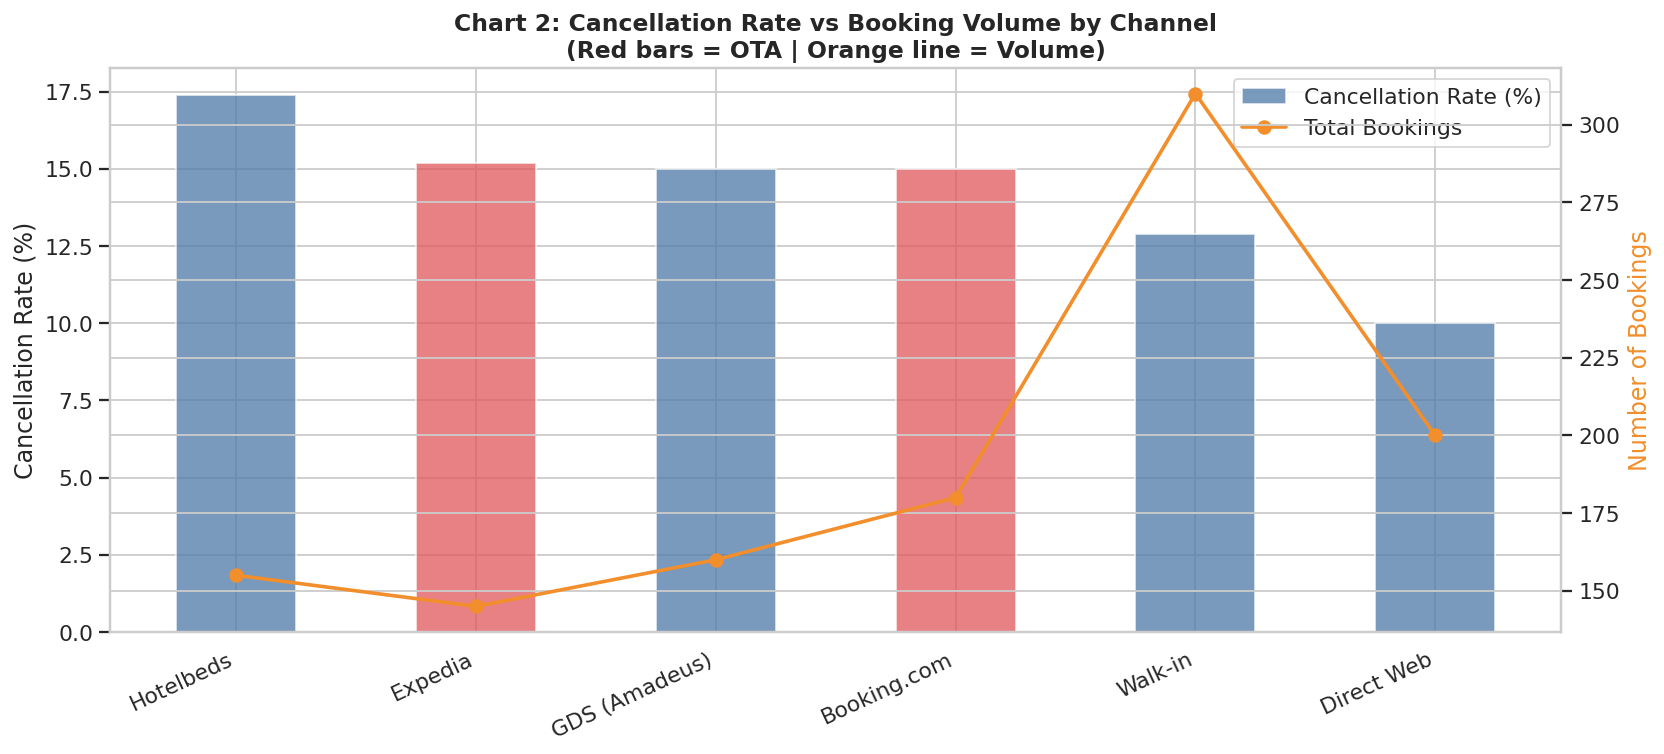

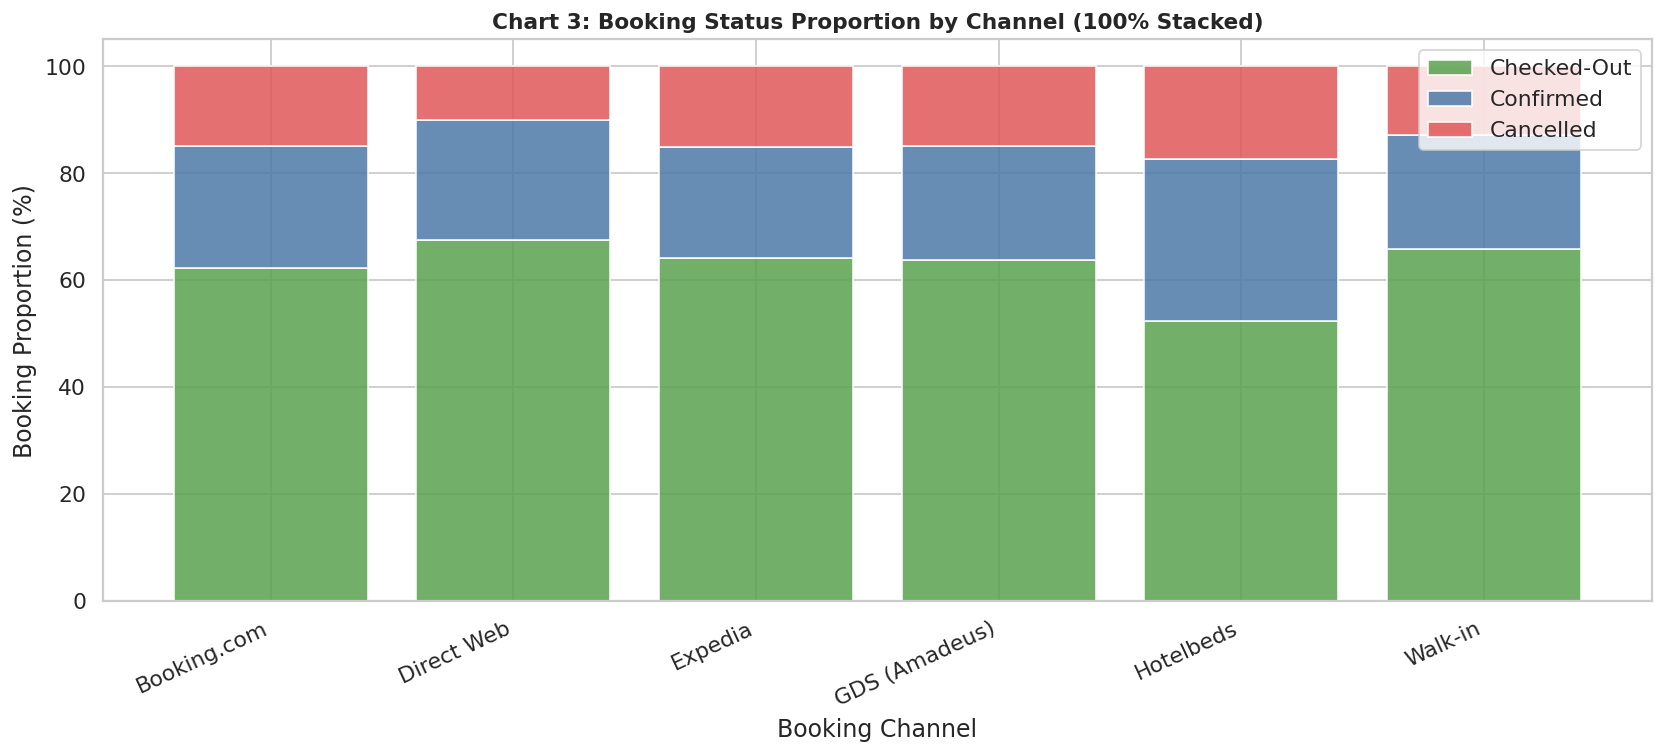

Charts 2 and 3 saved successfully


In [15]:
print('===== Hypothesis 3: Cancellation Rate by Channel =====')

cancel_summary = (df.groupby(['channel_name','channel_type'])
                  .agg(total_bookings=('booking_id','count'),
                       cancelled     =('is_cancelled','sum'))
                  .assign(cancel_rate=lambda x: (x['cancelled'] / x['total_bookings'] * 100).round(1))
                  .sort_values('cancel_rate', ascending=False)
                  .reset_index())

print(cancel_summary.to_string())

# Chart 2: Dual-axis Bar + Line
fig, ax1 = plt.subplots(figsize=(13,6))
ax2 = ax1.twinx()

x = np.arange(len(cancel_summary))
color_bar = ['#E15759' if t=='OTA' else '#4E79A7' for t in cancel_summary['channel_type']]

ax1.bar(x, cancel_summary['cancel_rate'], color=color_bar, alpha=0.75, width=0.5,
        label='Cancellation Rate (%)')
ax2.plot(x, cancel_summary['total_bookings'], color='#F28E2B', marker='o',
         linewidth=2, markersize=7, label='Total Bookings')

ax1.set_xticks(x)
ax1.set_xticklabels(cancel_summary['channel_name'], rotation=25, ha='right')
ax1.set_ylabel('Cancellation Rate (%)')
ax2.set_ylabel('Number of Bookings', color='#F28E2B')
ax1.set_title('Chart 2: Cancellation Rate vs Booking Volume by Channel\n(Red bars = OTA | Orange line = Volume)', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
plt.tight_layout()
plt.savefig('chart2_cancellation_rate.png', dpi=150)
plt.show()

# Chart 3: 100% Stacked Bar
status_pivot = (df.groupby(['channel_name','status'])
                .size().unstack(fill_value=0)
                .apply(lambda r: r/r.sum()*100, axis=1))
status_pivot = status_pivot.reindex(columns=['Checked-Out','Confirmed','Cancelled'], fill_value=0)
status_colors = {'Checked-Out':'#59A14F','Confirmed':'#4E79A7','Cancelled':'#E15759'}

fig, ax = plt.subplots(figsize=(13,6))
bottom = np.zeros(len(status_pivot))
for col in ['Checked-Out','Confirmed','Cancelled']:
    vals = status_pivot[col].values
    ax.bar(status_pivot.index, vals, bottom=bottom, label=col,
           color=status_colors[col], alpha=0.85)
    bottom += vals

ax.set_xlabel('Booking Channel')
ax.set_ylabel('Booking Proportion (%)')
ax.set_title('Chart 3: Booking Status Proportion by Channel (100% Stacked)', fontsize=12, fontweight='bold')
ax.set_xticklabels(status_pivot.index, rotation=25, ha='right')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('chart3_status_stacked.png', dpi=150)
plt.show()

print('Charts 2 and 3 saved successfully')

## เซลล์ที่ 7: ROI การตลาด — ต้นทุนจริงของช่องทางตรง
### แผนภูมิที่ 4: ค่าใช้จ่ายการตลาดรายเดือน

===== Marketing ROI and True Customer Acquisition Cost =====
Total marketing spend (THB)  :   224,308.66
Total clicks                 :       20,086
Direct Web bookings (active) :          180
Direct Web gross revenue     : 2,475,107.57
True COA % (Direct Web)      :          9.1%

→ Direct Web COA (9.1%) < OTA minimum (15%)


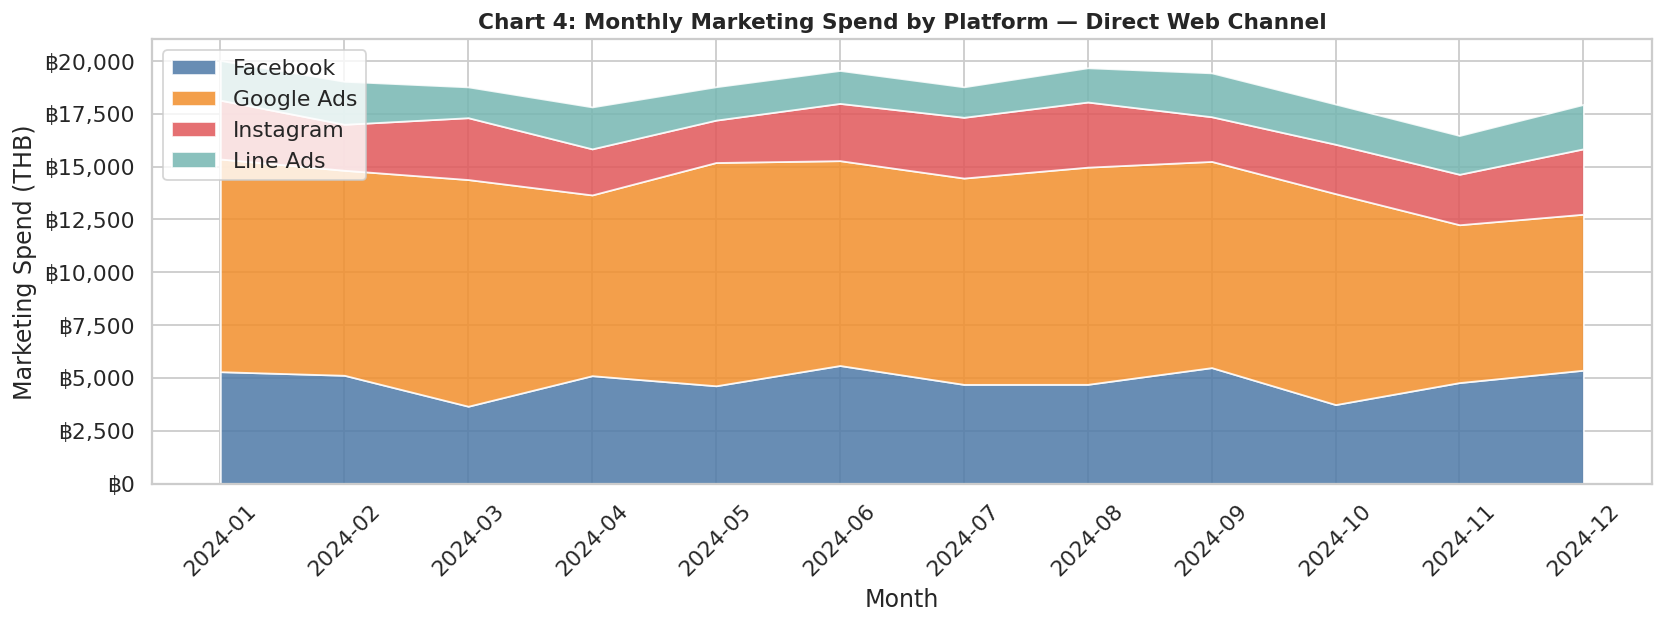

Saved: chart4_marketing_spend.png


In [16]:
print('===== Marketing ROI and True Customer Acquisition Cost =====')

total_mkt_spend = fact_mkt_spend['cost_amount'].sum()
total_clicks    = fact_mkt_spend['clicks'].sum()
direct_bookings = active_df[active_df['channel_id']=='CH_03']
direct_gross    = direct_bookings['gross_room_revenue'].sum()
direct_comm     = direct_bookings['commission_amount'].sum()

coa_direct = (direct_comm + total_mkt_spend) / direct_gross * 100

print(f'Total marketing spend (THB)  : {total_mkt_spend:>12,.2f}')
print(f'Total clicks                 : {total_clicks:>12,}')
print(f'Direct Web bookings (active) : {len(direct_bookings):>12,}')
print(f'Direct Web gross revenue     : {direct_gross:>12,.2f}')
print(f'True COA % (Direct Web)      : {coa_direct:>12.1f}%')
print(f'\n→ Direct Web COA ({coa_direct:.1f}%) {"<" if coa_direct < 15 else ">"} OTA minimum (15%)')

# Chart 4: Stacked Area
mkt_pivot = (fact_mkt_spend.groupby(
    [fact_mkt_spend['spend_date'].dt.strftime('%Y-%m'), 'platform'])
    ['cost_amount'].sum().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(13,5))
colors_plt = ['#4E79A7','#F28E2B','#E15759','#76B7B2']
ax.stackplot(mkt_pivot.index, [mkt_pivot[p] for p in mkt_pivot.columns],
             labels=mkt_pivot.columns, colors=colors_plt, alpha=0.85)
ax.set_xlabel('Month')
ax.set_ylabel('Marketing Spend (THB)')
ax.set_title('Chart 4: Monthly Marketing Spend by Platform — Direct Web Channel', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'฿{v:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart4_marketing_spend.png', dpi=150)
plt.show()

print('Saved: chart4_marketing_spend.png')

## เซลล์ที่ 8: สรุปคะแนนกำไร + แผนภูมิที่ 5

===== Channel Profitability Scorecard =====
 channel_name channel_type commission_model  bookings  net_adr  comm_pct  true_coa_pct  cancel_rate
      Walk-in       Direct         Flat Fee       270  13941.0       0.0           0.0         12.9
   Direct Web       Direct         Flat Fee       180  13751.0       0.0           9.1         10.0
      Expedia          OTA       Percentage       123  11023.0      18.0          18.0         15.2
GDS (Amadeus)    Wholesale         Flat Fee       136  10231.0       2.4           2.4         15.0
    Hotelbeds    Wholesale         Merchant       128   9192.0      12.7          12.7         17.4
  Booking.com          OTA       Percentage       153   8893.0      15.0          15.0         15.0


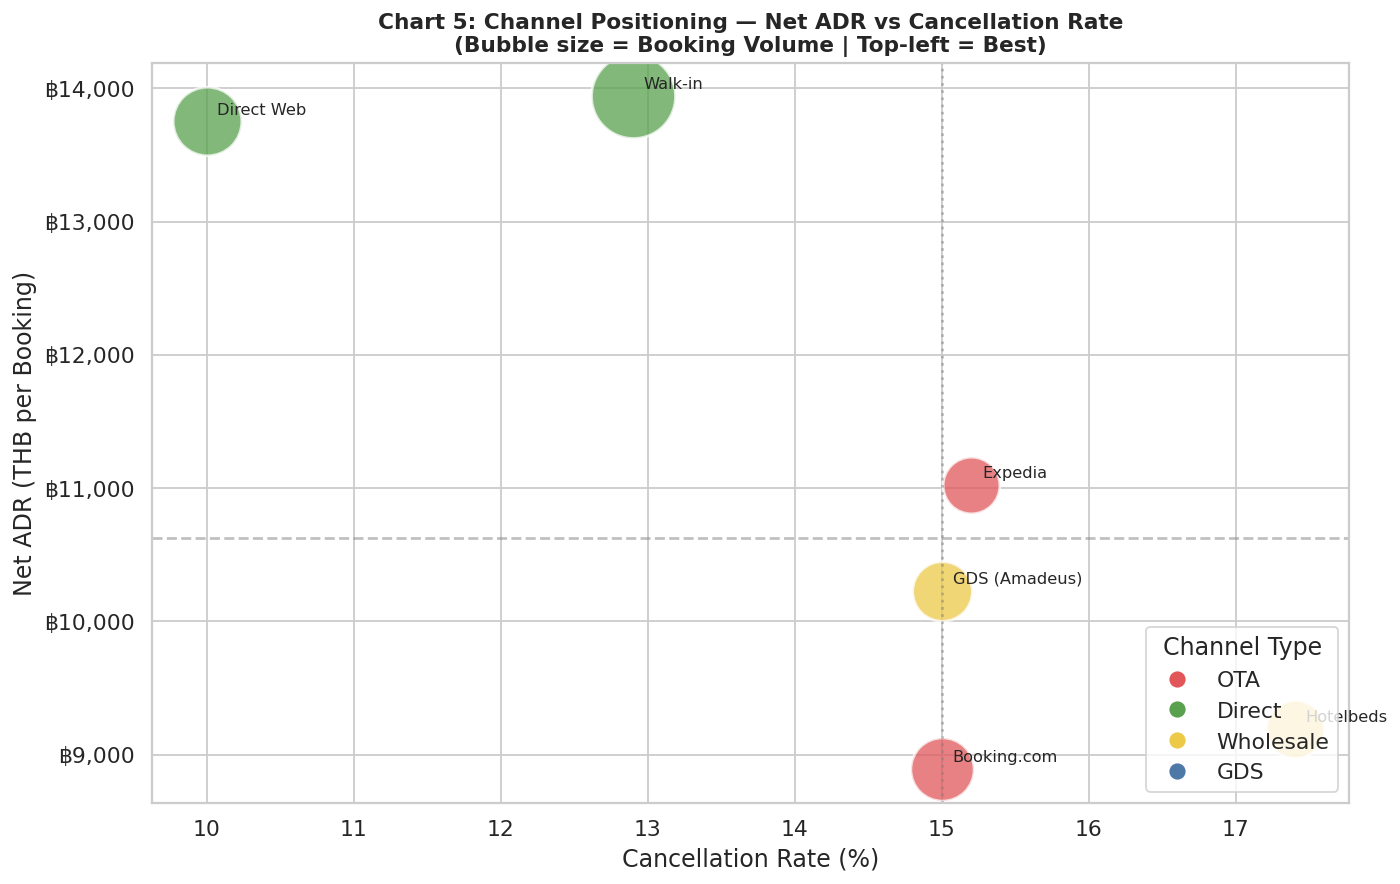

Saved: chart5_channel_scatter.png


In [17]:
print('===== Channel Profitability Scorecard =====')

scorecard = (active_df.groupby(['channel_id','channel_name','channel_type','commission_model'])
             .agg(bookings =('booking_id','count'),
                  gross_rev=('gross_room_revenue','sum'),
                  comm_cost=('commission_amount','sum'),
                  net_rev  =('net_room_revenue','sum'))
             .reset_index())

cancel_rate_map = (df.groupby('channel_id')
                   .apply(lambda x: x['is_cancelled'].sum()/len(x)*100)
                   .rename('cancel_rate'))
scorecard = scorecard.merge(cancel_rate_map, on='channel_id')

scorecard['marketing_spend'] = scorecard['channel_id'].apply(
    lambda c: total_mkt_spend if c == 'CH_03' else 0)
scorecard['net_adr']      = (scorecard['net_rev'] / scorecard['bookings']).round(0)
scorecard['comm_pct']     = (scorecard['comm_cost'] / scorecard['gross_rev'] * 100).round(1)
scorecard['true_coa_pct'] = ((scorecard['comm_cost'] + scorecard['marketing_spend']) / scorecard['gross_rev'] * 100).round(1)
scorecard['cancel_rate']  = scorecard['cancel_rate'].round(1)

display_cols = ['channel_name','channel_type','commission_model','bookings','net_adr','comm_pct','true_coa_pct','cancel_rate']
print(scorecard[display_cols].sort_values('net_adr', ascending=False).to_string(index=False))

# Chart 5: Bubble Chart
type_colors = {'OTA':'#E15759','Direct':'#59A14F','Wholesale':'#EDC948','GDS':'#4E79A7'}

fig, ax = plt.subplots(figsize=(11,7))
for _, row in scorecard.iterrows():
    color = type_colors.get(row['channel_type'], 'gray')
    ax.scatter(row['cancel_rate'], row['net_adr'],
               s=row['bookings']*8, color=color, alpha=0.75,
               edgecolors='white', linewidth=1.5)
    ax.annotate(row['channel_name'], (row['cancel_rate'], row['net_adr']),
                textcoords='offset points', xytext=(6,4), fontsize=9)

ax.axhline(y=scorecard['net_adr'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=scorecard['cancel_rate'].median(), color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Cancellation Rate (%)')
ax.set_ylabel('Net ADR (THB per Booking)')
ax.set_title('Chart 5: Channel Positioning — Net ADR vs Cancellation Rate\n(Bubble size = Booking Volume | Top-left = Best)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'฿{v:,.0f}'))

from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
                     markersize=10, label=t) for t,c in type_colors.items()]
ax.legend(handles=legend_els, title='Channel Type', loc='lower right')
plt.tight_layout()
plt.savefig('chart5_channel_scatter.png', dpi=150)
plt.show()

print('Saved: chart5_channel_scatter.png')

## เซลล์ที่ 8b: Chart 6 — Heatmap ค่าคอมมิชชันเฉลี่ยตามช่องทางและประเภทราคา

### ทำไมต้องใช้ Heatmap?
Heatmap เหมาะสมที่สุดเมื่อต้องการแสดงความสัมพันธ์ระหว่าง **2 ตัวแปรเชิงหมวดหมู่** (Channel × Rate Code) กับ **1 ตัวแปรเชิงตัวเลข** (Commission %) พร้อมกัน
การเข้ารหัสด้วยสีทำให้สมองมนุษย์เปรียบเทียบค่าได้เร็วกว่าการอ่านตัวเลขในตาราง (Pre-attentive Processing)
แผนภูมิอื่น ๆ ที่พิจารณา:
- **Grouped Bar**: รองรับได้แค่ ~3 กลุ่ม ถ้ามี 6 ช่องทาง × 4 Rate Code จะรกมาก
- **Scatter Plot**: ใช้สำหรับตัวแปรต่อเนื่อง ไม่ใช่หมวดหมู่
- **Line Chart**: หมวดหมู่ไม่มีลำดับ (nominal) จึงไม่ควรใช้เส้น

**สิ่งที่ Heatmap นี้ตอบ:** ช่องทาง + Rate Code ใดที่รวมกันแล้วมี Commission Cost สูงที่สุด?
ข้อมูลนี้ช่วยให้ Revenue Manager รู้ว่าจะ *จำกัดโควตาห้องพักคู่ใด* ก่อนเป็นลำดับแรก

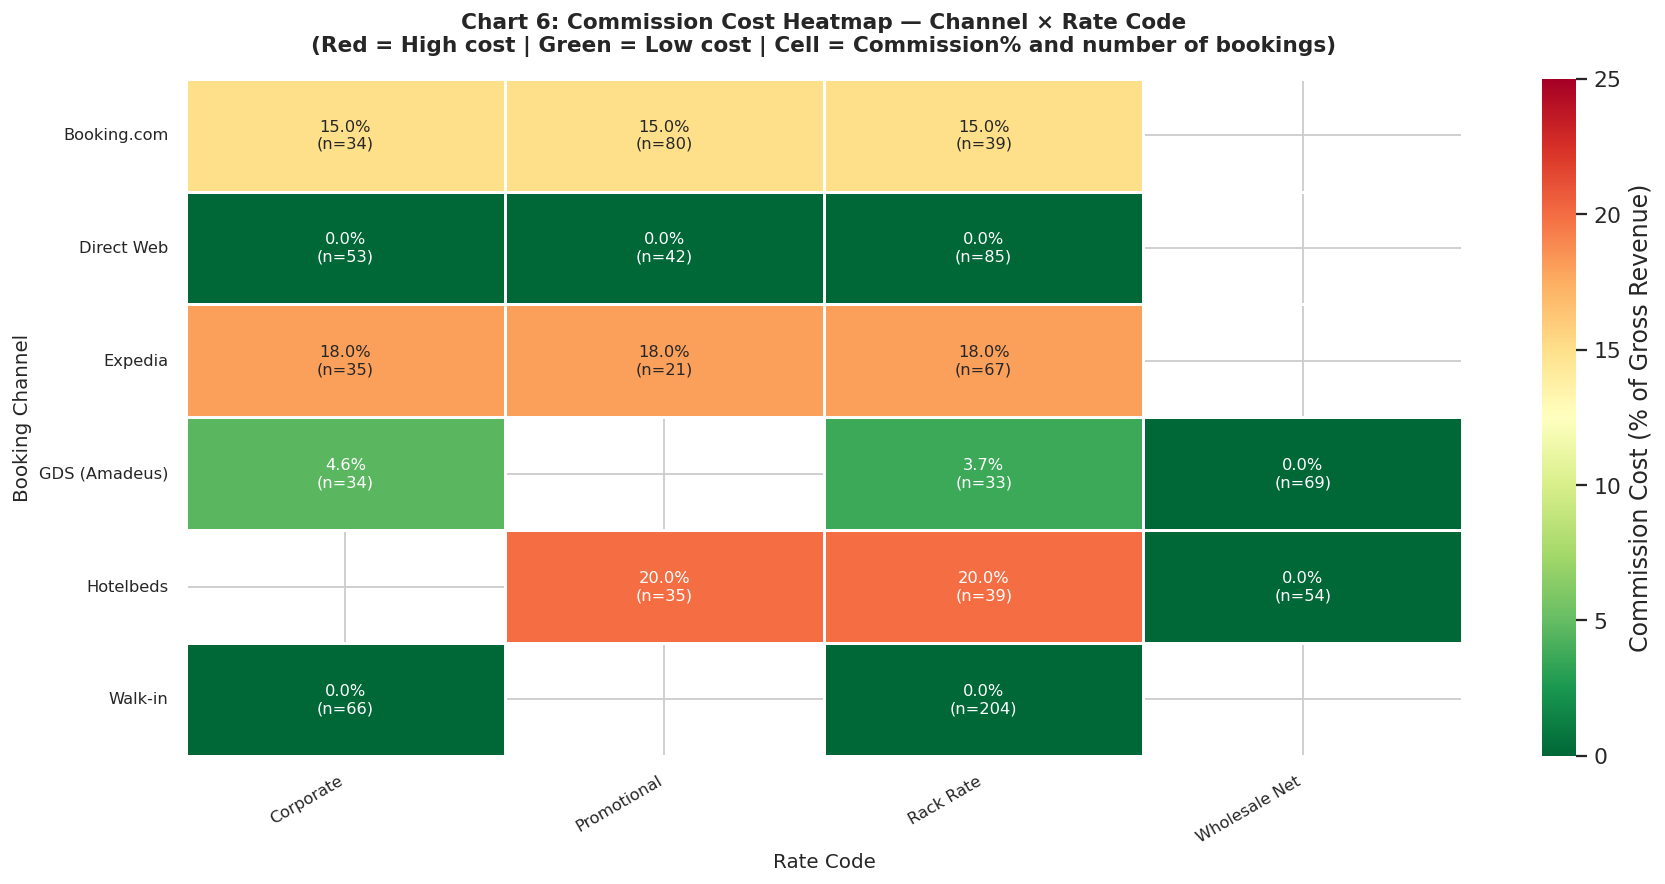

Saved: chart6_heatmap_commission.png

===== Summary from Heatmap =====
Top 5 highest commission cost pairs (should reduce allocation):
channel_name   rate_name  comm_pct  bookings
   Hotelbeds Promotional      20.0        35
   Hotelbeds   Rack Rate      20.0        39
     Expedia   Corporate      18.0        35
     Expedia Promotional      18.0        21
     Expedia   Rack Rate      18.0        67

Pairs with 0% commission (should increase allocation):
 channel_name     rate_name  comm_pct  bookings
      Walk-in     Rack Rate       0.0       204
   Direct Web     Rack Rate       0.0        85
GDS (Amadeus) Wholesale Net       0.0        69
      Walk-in     Corporate       0.0        66
    Hotelbeds Wholesale Net       0.0        54


In [18]:
# ============================================================
# Chart 6: Heatmap — Commission % by Channel × Rate Code
# ============================================================
# เป้าหมาย: หาคู่ (ช่องทาง × ประเภทราคา) ที่กินกำไรมากที่สุด
# ข้อมูลที่ใช้: commission_amount, gross_room_revenue
#              จาก fact_bookings + dim_channels + dim_rate_codes
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import numpy as np

# คำนวณ Commission % สำหรับแต่ละคู่ (channel × rate_code)
# ใช้ active_df (ตัด Cancelled ออก) เพราะต้องการต้นทุนที่เกิดขึ้นจริง
heatmap_data = (
    active_df
    .groupby(['channel_name', 'rate_name'])
    .agg(
        total_gross=('gross_room_revenue', 'sum'),
        total_comm =('commission_amount',  'sum'),
        bookings   =('booking_id',         'count')
    )
    .assign(comm_pct=lambda x: (x['total_comm'] / x['total_gross'] * 100).round(1))
    .reset_index()
)

# Pivot เพื่อสร้าง matrix: แถว = channel, คอลัมน์ = rate code
heatmap_pivot = heatmap_data.pivot_table(
    index='channel_name',
    columns='rate_name',
    values='comm_pct',
    aggfunc='mean'
)

# Pivot สำหรับ annotation (จำนวน bookings)
count_pivot = heatmap_data.pivot_table(
    index='channel_name',
    columns='rate_name',
    values='bookings',
    aggfunc='sum'
)

# สร้าง annotation string: แสดงทั้ง % และจำนวน booking
annot_labels = heatmap_pivot.copy().astype(object)
for row in heatmap_pivot.index:
    for col in heatmap_pivot.columns:
        pct = heatmap_pivot.loc[row, col]
        cnt = count_pivot.loc[row, col] if (row in count_pivot.index and col in count_pivot.columns) else np.nan
        if not np.isnan(pct):
            annot_labels.loc[row, col] = f"{pct:.1f}%\n(n={int(cnt) if not np.isnan(cnt) else 0})"
        else:
            annot_labels.loc[row, col] = "-"

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    heatmap_pivot,
    annot=annot_labels,
    fmt='',
    cmap='RdYlGn_r',          # แดง = ต้นทุนสูง, เขียว = ต้นทุนต่ำ
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': 'Commission Cost (% of Gross Revenue)'},
    vmin=0, vmax=25,
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title(
    'Chart 6: Commission Cost Heatmap — Channel × Rate Code\n'
    '(Red = High cost | Green = Low cost | Cell = Commission% and number of bookings)',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xlabel('Rate Code', fontsize=11)
ax.set_ylabel('Booking Channel', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=9)

plt.tight_layout()
plt.savefig('chart6_heatmap_commission.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart6_heatmap_commission.png')

# --- สรุปผล Heatmap ---
print('\n===== Summary from Heatmap =====')

# หาคู่ที่แย่ที่สุด (Commission สูงสุด)
worst = heatmap_data.nlargest(5, 'comm_pct')[['channel_name','rate_name','comm_pct','bookings']]
print('Top 5 highest commission cost pairs (should reduce allocation):')
print(worst.to_string(index=False))
print()

# หาคู่ที่ดีที่สุด
best = heatmap_data[heatmap_data['comm_pct']==0].nlargest(5,'bookings')[['channel_name','rate_name','comm_pct','bookings']]
print('Pairs with 0% commission (should increase allocation):')
print(best.to_string(index=False))

## เซลล์ที่ 9: สรุปผลการวิเคราะห์และข้อเสนอแนะ

In [13]:
print("""
AZURE STAY - Channel Profitability Analysis Results
-------------------------------------------------------
Finding 1 (Commission Trap & Direct Advantage)
  Direct channel = 44.3% of bookings, Net ADR 13,751 THB
  OTA Net ADR 8,893-11,023 THB (commission 15-18% per booking)
  True COA Direct Web = 9.1% vs OTA avg 16.5%
  -> Direct channel wins on both Net ADR and True COA

Finding 2 (Serial Cancellers)
  Promotional Rate cancel rate ~24.6% vs Corporate ~10.1%
  Hotelbeds highest cancel rate at 17.4%
  -> OTA + Promo Rate = double damage: high commission + high cancel

Finding 3 (Heatmap - Channel x Rate Code)
  Hotelbeds x Promo/Rack = 20%, Expedia x all = 18%
  Direct Web & Walk-in = 0% across all rate codes
  -> Reduce quota for Hotelbeds+Expedia, shift to Direct Web

Recommendation 1: Shift RT_PROMO to Non-Refundable policy
Recommendation 2: Redirect OTA budget to Direct channel
Recommendation 3: Expand Corporate Rate contracts
""")
print('Analysis complete. All charts saved.')



AZURE STAY - Channel Profitability Analysis Results
-------------------------------------------------------
Finding 1 (Commission Trap & Direct Advantage)
  Direct channel = 44.3% of bookings, Net ADR 13,751 THB
  OTA Net ADR 8,893-11,023 THB (commission 15-18% per booking)
  True COA Direct Web = 9.1% vs OTA avg 16.5%
  -> Direct channel wins on both Net ADR and True COA

Finding 2 (Serial Cancellers)
  Promotional Rate cancel rate ~24.6% vs Corporate ~10.1%
  Hotelbeds highest cancel rate at 17.4%
  -> OTA + Promo Rate = double damage: high commission + high cancel

Finding 3 (Heatmap - Channel x Rate Code)
  Hotelbeds x Promo/Rack = 20%, Expedia x all = 18%
  Direct Web & Walk-in = 0% across all rate codes
  -> Reduce quota for Hotelbeds+Expedia, shift to Direct Web

Recommendation 1: Shift RT_PROMO to Non-Refundable policy
Recommendation 2: Redirect OTA budget to Direct channel
Recommendation 3: Expand Corporate Rate contracts

Analysis complete. All charts saved.
